# 01 · Comprensión de datos y consolidación

**Etapa 1 (CRISP-DM) · Sección 7.2** — Trufi App, Área Metropolitana de Cochabamba

Este notebook parte de los 85 CSV crudos de exportación semanal (`data/raw/*.csv`) y entrega un dataset consolidado, auditado y tesselado en celdas H3 — la base sobre la que se construirán las siguientes etapas del proyecto.

**Objetivo del proyecto (OE1)**, para contexto — este notebook es su cimiento, no lo resuelve:

> Construir una tabla minable a nivel de celda H3 res. 8 que integre conteos de consultas, población Kontur, distancia a la Plaza 14 de Septiembre, métricas de cobertura GTFS derivadas solo de la geometría de rutas y rezagos espaciales de vecinos (k-ring). Entregable: tabla y diccionario de datos (7.3).

## Contenido
1. Configuración del entorno
2. Auditoría de los 85 CSV crudos
3. Consolidación a Parquet
4. Calidad de datos: nulos y duplicados
5. Comprobación de la columna `distancia`
6. Análisis de consultas: cobertura temporal y distribución espacial
7. Análisis de `userID`
8. Proporciones por variable y por zona
9. Celdas H3 (formato Kontur, resolución 8)
10. Consolidación final y resumen

## 1. Configuración del entorno

Todas las librerías usadas en este notebook vienen de un único módulo compartido (`trufi_ds.notebook_setup`), para no repetir imports dispersos. También se importa `utils.read_csv_safe` (helper específico de lectura de crudo, reutilizado tal cual) y `trufi_ds.config.BBOX`.

(La primera celda solo ubica `src/` en `sys.path` — es el único paso que no puede venir del propio `trufi_ds`, porque hasta este punto `trufi_ds` todavía no es importable.)

In [1]:
import sys
from pathlib import Path

_raiz = Path.cwd()
while not (_raiz / "pyproject.toml").exists():
    _raiz = _raiz.parent
_src = str(_raiz / "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

In [2]:
from trufi_ds.notebook_setup import *  # noqa: F403
from utils import ENCODING_ISSUES, read_csv_safe
from trufi_ds.config import BBOX

crear_directorios("01_data_understanding")

CARPETA_RAW = PROJECT_ROOT / "data" / "raw"
CARPETA_INTERIM = PROJECT_ROOT / "data" / "interim"
CARPETA_REPORTES = PROJECT_ROOT / "reports" / "01_data_understanding"
print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: /home/robvox/Desktop/trufi-data-science


## 2. Auditoría de los 85 CSV crudos

Antes de concatenar, hay que confirmar que los 85 archivos comparten el mismo esquema — no asumirlo. Se compara cada archivo contra el primero (referencia).

In [3]:
archivos_csv = sorted(CARPETA_RAW.glob("*.csv"))
print(f"Total de archivos CSV: {len(archivos_csv)}")

esquemas = {}
for archivo in archivos_csv:
    df_encabezado = read_csv_safe(archivo, n_rows=0)
    esquemas[archivo.name] = list(df_encabezado.columns)

archivo_referencia = archivos_csv[0].name
columnas_referencia = set(esquemas[archivo_referencia])

filas_reporte = []
for nombre, columnas in esquemas.items():
    columnas_set = set(columnas)
    filas_reporte.append({
        "archivo": nombre,
        "n_columnas": len(columnas),
        "faltan_vs_referencia": ", ".join(sorted(columnas_referencia - columnas_set)),
        "sobran_vs_referencia": ", ".join(sorted(columnas_set - columnas_referencia)),
        "identico": columnas_set == columnas_referencia,
    })

df_diferencias_esquema = pl.DataFrame(filas_reporte)
df_diferencias_esquema.write_csv(CARPETA_REPORTES / "schema_diff.csv")

n_identicos = df_diferencias_esquema["identico"].sum()
print(f"Archivo de referencia: {archivo_referencia}")
print(f"Columnas de referencia ({len(columnas_referencia)}): {sorted(columnas_referencia)}")
print(f"Archivos idénticos a la referencia: {n_identicos}/{len(archivos_csv)}")
df_diferencias_esquema.filter(~pl.col("identico"))

Total de archivos CSV: 85


Archivo de referencia: 2022-09-12_to_2022-09-18_2022-37.csv
Columnas de referencia (13): ['date', 'dest_municipio', 'destination_latitude', 'destination_longitude', 'dia_de_mes', 'dia_de_semana', 'distancia', 'fin_de_semana', 'hora', 'origin_latitude', 'origin_longitude', 'origin_municipio', 'userID']
Archivos idénticos a la referencia: 79/85


archivo,n_columnas,faltan_vs_referencia,sobran_vs_referencia,identico
str,i64,str,str,bool
"""2024-04-29_to_2024-05-05_2024-…",15,"""dia_de_mes, dia_de_semana, fin…","""day_of_month, day_of_week, hou…",false
"""2024-05-06_to_2024-05-12_2024-…",15,"""dia_de_mes, dia_de_semana, fin…","""day_of_month, day_of_week, hou…",false
"""2024-05-13_to_2024-05-19_2024-…",15,"""dia_de_mes, dia_de_semana, fin…","""day_of_month, day_of_week, hou…",false
"""2024-05-20_to_2024-05-26_2024-…",15,"""dia_de_mes, dia_de_semana, fin…","""day_of_month, day_of_week, hou…",false
"""2024-05-27_to_2024-06-02_2024-…",15,"""dia_de_mes, dia_de_semana, fin…","""day_of_month, day_of_week, hou…",false
"""2024-06-03_to_2024-06-09_2024-…",15,"""dia_de_mes, dia_de_semana, fin…","""day_of_month, day_of_week, hou…",false


**Hallazgo**: 6 archivos difieren — todos del lote de exportación más reciente (`2024-04-29` a `2024-06-09`). Usan nombres de columna en inglés (`hour`, `day_of_week`, `day_of_month`, `weekend`) en vez de español (`hora`, `dia_de_semana`, `dia_de_mes`, `fin_de_semana`), y agregan dos columnas nuevas (`year_week_number`, `time_of_day`).

Esos mismos 6 archivos también traen caracteres acentuados en codificación Latin-1 (p. ej. "Villa Santivañez") mezclados en un archivo que de otro modo es UTF-8 — se maneja con `utils.read_csv_safe`, que reintenta con Latin-1 si falla la lectura UTF-8. **Nota importante**: el conteo de archivos afectados por codificación solo es confiable tomándolo de una lectura completa del archivo (ver sección 3) — una lectura de solo encabezado (`n_rows=0`, usada arriba solo para el esquema) puede no llegar a los bytes problemáticos si están más adelante en el archivo.

## 3. Consolidación a Parquet

Se normalizan las dos variantes de esquema a un solo conjunto de columnas (para que un campo equivalente no quede disperso en dos columnas sparse) y se concatenan los 85 archivos.

**Por qué Parquet particionado (`year=/week=`)**: permite que las etapas siguientes lean solo las particiones que necesitan en vez de todo el archivo, y preserva tipos de dato (a diferencia de CSV) — `pl.read_parquet` sobre el directorio completo lo trata como un solo dataset, transparente para quien lo consume.

In [4]:
RENOMBRAR_ESPANOL_A_INGLES = {
    "hora": "hour",
    "dia_de_semana": "day_of_week",
    "dia_de_mes": "day_of_month",
    "fin_de_semana": "weekend",
}

ENCODING_ISSUES.clear()  # esta lectura completa es la confiable

marcos = []
filas_esperadas = 0
for archivo in archivos_csv:
    df = read_csv_safe(archivo, infer_schema_length=10000, try_parse_dates=False)
    filas_esperadas += len(df)

    renombres = {k: v for k, v in RENOMBRAR_ESPANOL_A_INGLES.items() if k in df.columns}
    if renombres:
        df = df.rename(renombres)

    es_lote_nuevo = "year_week_number" in df.columns
    df = df.with_columns(
        pl.lit(archivo.name).alias("source_file"),
        pl.lit("lote_2024_nuevo" if es_lote_nuevo else "lote_original").alias("source_batch"),
    )
    marcos.append(df)

df_consultas = pl.concat(marcos, how="diagonal_relaxed")

# Nombres cortos y canónicos para las coordenadas, usados en todo el proyecto.
df_consultas = df_consultas.rename({
    "origin_latitude": "lat_orig",
    "origin_longitude": "lon_orig",
    "destination_latitude": "lat_dest",
    "destination_longitude": "lon_dest",
})

df_consultas = df_consultas.with_columns(pl.col("date").str.to_datetime(strict=False).alias("ts"))
df_consultas = df_consultas.with_columns([
    pl.col("ts").dt.year().alias("year"),
    pl.col("ts").dt.week().alias("week"),
])

total_filas = len(df_consultas)
print(f"Filas leídas de los CSV (suma):  {filas_esperadas:,}")
print(f"Filas en el marco consolidado:   {total_filas:,}")
print(f"Coinciden (sin pérdida ni duplicación): {filas_esperadas == total_filas}")
print(f"\nArchivos que requirieron fallback Latin-1 ({len(ENCODING_ISSUES)}):")
for nombre in ENCODING_ISSUES:
    print(f"  {nombre}")
df_consultas.group_by("source_batch").agg(pl.len().alias("n"))

Filas leídas de los CSV (suma):  1,927,675
Filas en el marco consolidado:   1,927,675
Coinciden (sin pérdida ni duplicación): True

Archivos que requirieron fallback Latin-1 (6):
  2024-04-29_to_2024-05-05_2024-18.csv
  2024-05-06_to_2024-05-12_2024-19.csv
  2024-05-13_to_2024-05-19_2024-20.csv
  2024-05-20_to_2024-05-26_2024-21.csv
  2024-05-27_to_2024-06-02_2024-22.csv
  2024-06-03_to_2024-06-09_2024-23.csv


source_batch,n
str,u32
"""lote_original""",1765898
"""lote_2024_nuevo""",161777


In [5]:
ruta_parquet = CARPETA_INTERIM / "queries.parquet"
df_consultas.write_parquet(ruta_parquet, partition_by=["year", "week"])
print(f"Guardado: {ruta_parquet}/ (particionado por year, week)")
print(f"Columnas ({len(df_consultas.columns)}): {df_consultas.columns}")

Guardado: /home/robvox/Desktop/trufi-data-science/data/interim/queries.parquet/ (particionado por year, week)
Columnas (20): ['date', 'lat_orig', 'lon_orig', 'lat_dest', 'lon_dest', 'userID', 'distancia', 'origin_municipio', 'dest_municipio', 'hour', 'day_of_week', 'day_of_month', 'weekend', 'source_file', 'source_batch', 'year_week_number', 'time_of_day', 'ts', 'year', 'week']


## 4. Calidad de datos: nulos y duplicados

Este notebook **diagnostica, no filtra** — las decisiones de qué eliminar se documentan aquí, pero el borrado real de filas es responsabilidad de la Etapa 2 (`src/09_select_filter.py`).

In [6]:
nulos = (
    df_consultas.select([pl.col(c).is_null().sum().alias(c) for c in df_consultas.columns])
    .transpose(include_header=True, header_name="columna", column_names=["nulos"])
    .with_columns((pl.col("nulos") / total_filas * 100).round(3).alias("pct"))
    .sort("nulos", descending=True)
)
nulos

columna,nulos,pct
str,u32,f64
"""year_week_number""",1765898,91.608
"""time_of_day""",1765898,91.608
"""date""",0,0.0
"""lat_orig""",0,0.0
"""lon_orig""",0,0.0
…,…,…
"""source_file""",0,0.0
"""source_batch""",0,0.0
"""ts""",0,0.0


In [7]:
duplicados_exactos = df_consultas.is_duplicated().sum()

claves_negocio = [c for c in ["ts", "lat_orig", "lon_orig", "lat_dest", "lon_dest"] if c in df_consultas.columns]
duplicados_od_ts = df_consultas.select(claves_negocio).is_duplicated().sum()
duplicados_user_ts = df_consultas.select(["userID", "ts"]).is_duplicated().sum()

n_userid_nulo = df_consultas["userID"].is_null().sum()

print(f"Duplicados exactos (todas las columnas): {duplicados_exactos:,} ({duplicados_exactos/total_filas*100:.3f}%) -> decisión: eliminar en Etapa 2")
print(f"Duplicados en OD + ts:                   {duplicados_od_ts:,} ({duplicados_od_ts/total_filas*100:.3f}%)")
print(f"Duplicados en userID + ts:                {duplicados_user_ts:,} ({duplicados_user_ts/total_filas*100:.3f}%) -> decisión: conservar, resolver por sesionización")
print(f"\nuserID nulo: {n_userid_nulo:,}")

Duplicados exactos (todas las columnas): 104 (0.005%) -> decisión: eliminar en Etapa 2
Duplicados en OD + ts:                   104 (0.005%)
Duplicados en userID + ts:                137 (0.007%) -> decisión: conservar, resolver por sesionización

userID nulo: 0


## 5. ¿`distancia` es haversine o distancia de la mejor ruta?

El crudo trae un solo campo (`distancia`) sin indicar su naturaleza. Se determina empíricamente: se recalcula la distancia geodésica (haversine, línea recta) entre origen y destino sobre una muestra, y se compara contra la columna cruda. Si coinciden con alta correlación y bajo error, **no** es distancia de ruta real (que sería mayor, salvo casos triviales) — es línea recta.

In [8]:
RADIO_TIERRA_M = 6371000


def haversine_vectorizado(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * RADIO_TIERRA_M * np.arcsin(np.sqrt(a))


muestra = df_consultas.sample(n=min(200_000, total_filas), seed=42)
distancia_calculada = haversine_vectorizado(
    muestra["lat_orig"].to_numpy(), muestra["lon_orig"].to_numpy(),
    muestra["lat_dest"].to_numpy(), muestra["lon_dest"].to_numpy(),
)
distancia_cruda = muestra["distancia"].to_numpy()

error_relativo_metros = np.abs(distancia_calculada - distancia_cruda) / np.clip(np.abs(distancia_cruda), 1, None)
error_relativo_km = np.abs(distancia_calculada - distancia_cruda * 1000) / np.clip(np.abs(distancia_cruda * 1000), 1, None)
correlacion = np.corrcoef(distancia_calculada, distancia_cruda)[0, 1]

pct_1pct_metros = float(np.mean(error_relativo_metros < 0.01) * 100)
pct_1pct_km = float(np.mean(error_relativo_km < 0.01) * 100)

print(f"n = {len(muestra):,}")
print(f"Correlación (cruda vs. recalculada): {correlacion:.6f}")
print(f"Mediana error relativo (asumiendo metros): {np.median(error_relativo_metros):.6f}")
print(f"% dentro de 1% de error (metros):          {pct_1pct_metros:.2f}%")
print(f"% dentro de 1% de error (kilómetros x1000): {pct_1pct_km:.2f}%")

conclusion_unidad = "metros" if pct_1pct_metros > pct_1pct_km else "kilómetros"
print(f"\nConclusión: `distancia` está en {conclusion_unidad}, es distancia en línea recta (haversine/geodésica), no de ruta real.")

n = 200,000
Correlación (cruda vs. recalculada): 0.999997
Mediana error relativo (asumiendo metros): 0.001417
% dentro de 1% de error (metros):          100.00%
% dentro de 1% de error (kilómetros x1000): 0.00%

Conclusión: `distancia` está en metros, es distancia en línea recta (haversine/geodésica), no de ruta real.


## 6. Análisis de consultas: cobertura temporal y distribución espacial

### 6.1 Vacíos de registro (cobertura temporal)

Se construye la grilla semanal esperada entre la primera y última consulta y se compara contra las semanas realmente presentes.

In [9]:
fecha_min, fecha_max = df_consultas["ts"].min(), df_consultas["ts"].max()
print(f"Cobertura real: {fecha_min} a {fecha_max}")

semanal = (
    df_consultas.sort("ts")
    .group_by_dynamic("ts", every="1w")
    .agg(pl.len().alias("n"))
    .with_columns(pl.col("ts").dt.date().alias("semana"))
)
semanas_esperadas = pl.date_range(fecha_min.date(), fecha_max.date(), interval="1w", eager=True).alias("semana")

semanal_completo = (
    pl.DataFrame({"semana": semanas_esperadas})
    .join(semanal.select(["semana", "n"]), on="semana", how="left")
    .with_columns(pl.col("n").fill_null(0))
)
semanas_vacias = semanal_completo.filter(pl.col("n") == 0)
print(f"Semanas esperadas: {len(semanal_completo)}")
print(f"Semanas sin datos (vacíos de registro): {len(semanas_vacias)}")
semanas_vacias

Cobertura real: 2022-09-12 09:55:24 a 2024-06-03 11:01:07


Semanas esperadas: 91
Semanas sin datos (vacíos de registro): 7


semana,n
date,u32
2024-03-11,0
2024-03-18,0
2024-03-25,0
2024-04-01,0
2024-04-08,0
2024-04-15,0
2024-04-22,0


### 6.2 Distribución espacial: bbox metropolitano

Documenta cuántas consultas caen fuera del bbox de Cochabamba metropolitana (no se eliminan — pueden ser viajes interurbanos legítimos).

In [10]:
df_dentro_bbox = df_consultas.filter(
    pl.col("lat_orig").is_between(BBOX["lat_min"], BBOX["lat_max"])
    & pl.col("lon_orig").is_between(BBOX["lon_min"], BBOX["lon_max"])
    & pl.col("lat_dest").is_between(BBOX["lat_min"], BBOX["lat_max"])
    & pl.col("lon_dest").is_between(BBOX["lon_min"], BBOX["lon_max"])
)
n_dentro = len(df_dentro_bbox)
n_fuera = total_filas - n_dentro
print(f"Dentro del bbox: {n_dentro:,} ({n_dentro/total_filas*100:.2f}%)")
print(f"Fuera del bbox:  {n_fuera:,} ({n_fuera/total_filas*100:.2f}%)")

coordenadas_cero = df_consultas.filter(
    (pl.col("lat_orig") == 0) | (pl.col("lon_orig") == 0)
    | (pl.col("lat_dest") == 0) | (pl.col("lon_dest") == 0)
).height
print(f"Coordenadas cero: {coordenadas_cero:,}")

Dentro del bbox: 1,924,161 (99.82%)
Fuera del bbox:  3,514 (0.18%)


Coordenadas cero: 3


**Un hallazgo adicional, no documentado en el análisis original**: "fuera del bbox metropolitano" no es lo mismo que "coordenada imposible". La mayoría de las 3,514 filas fuera del bbox son viajes interurbanos reales dentro de Bolivia (Tarata, Capinota, etc.); pero unas pocas filas tienen coordenadas físicamente imposibles para Bolivia (Bolivia continental está aprox. entre lat -23/-9, lon -70/-56). Se cuentan por separado, con un bbox amplio de Bolivia, no el bbox metropolitano estrecho.

In [11]:
BBOX_BOLIVIA = {"lat_min": -23, "lat_max": -9, "lon_min": -70, "lon_max": -56}

df_dentro_bolivia = df_consultas.filter(
    pl.col("lat_orig").is_between(BBOX_BOLIVIA["lat_min"], BBOX_BOLIVIA["lat_max"])
    & pl.col("lon_orig").is_between(BBOX_BOLIVIA["lon_min"], BBOX_BOLIVIA["lon_max"])
    & pl.col("lat_dest").is_between(BBOX_BOLIVIA["lat_min"], BBOX_BOLIVIA["lat_max"])
    & pl.col("lon_dest").is_between(BBOX_BOLIVIA["lon_min"], BBOX_BOLIVIA["lon_max"])
)
n_coordenadas_imposibles = total_filas - len(df_dentro_bolivia)
print(f"Coordenadas físicamente imposibles para Bolivia: {n_coordenadas_imposibles:,}")
print(
    f"(de las {n_fuera:,} filas fuera del bbox metropolitano, "
    f"{n_fuera - n_coordenadas_imposibles:,} son interurbanas legítimas dentro de Bolivia "
    f"y {n_coordenadas_imposibles:,} son error de coordenadas real)"
)

Coordenadas físicamente imposibles para Bolivia: 15
(de las 3,514 filas fuera del bbox metropolitano, 3,499 son interurbanas legítimas dentro de Bolivia y 15 son error de coordenadas real)


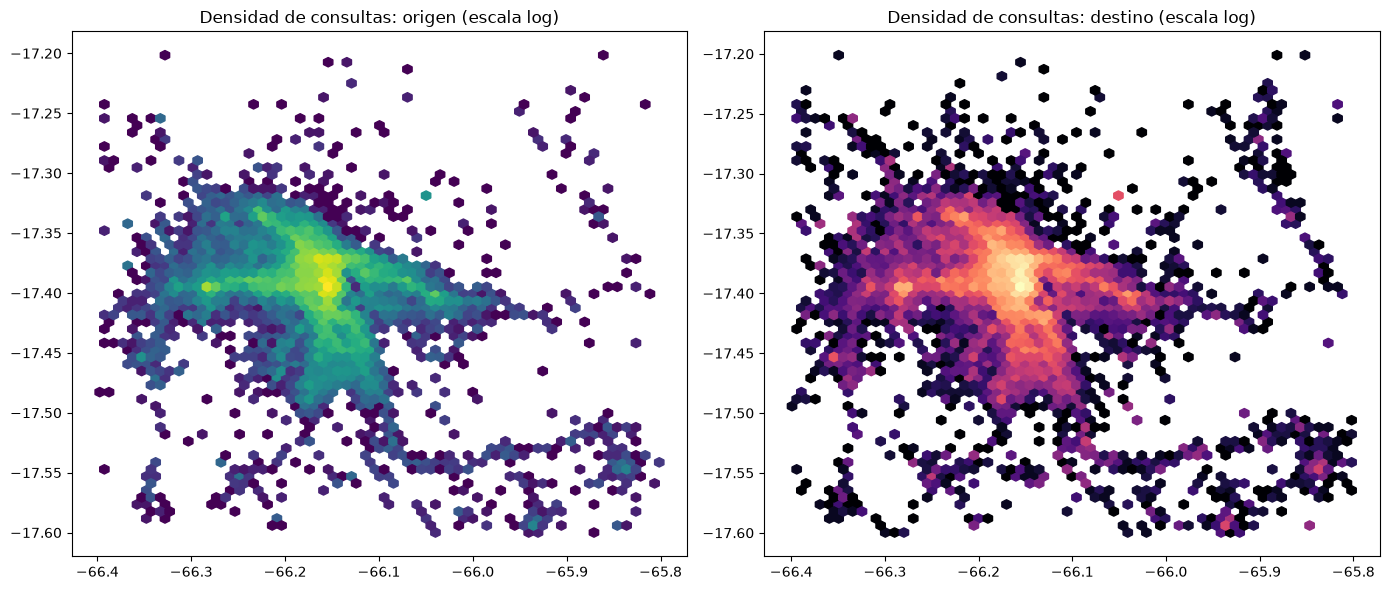

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))
ejes[0].hexbin(
    df_dentro_bbox["lon_orig"].to_numpy(), df_dentro_bbox["lat_orig"].to_numpy(),
    gridsize=60, cmap="viridis", bins="log",
)
ejes[0].set_title("Densidad de consultas: origen (escala log)")
ejes[1].hexbin(
    df_dentro_bbox["lon_dest"].to_numpy(), df_dentro_bbox["lat_dest"].to_numpy(),
    gridsize=60, cmap="magma", bins="log",
)
ejes[1].set_title("Densidad de consultas: destino (escala log)")
plt.tight_layout()
guardar_figura(fig, "mapa_calor_origen_destino_crudo")
plt.show()

## 7. Análisis de `userID`

El análisis más decisivo del proyecto: si `userID` es a nivel instalación (uso repetido, persiste en el tiempo) un target individual es viable; si es efímero por sesión, hay que pivotar a análisis por celda desde el inicio.

In [13]:
por_usuario = df_consultas.group_by("userID").agg([
    pl.len().alias("n_consultas"),
    pl.col("ts").min().alias("primera_consulta"),
    pl.col("ts").max().alias("ultima_consulta"),
    (pl.col("ts").max() - pl.col("ts").min()).dt.total_days().alias("dias_de_vida"),
    pl.col("ts").dt.year().n_unique().alias("n_anios"),
])
n_usuarios = len(por_usuario)
n_consultas_total = por_usuario["n_consultas"].sum()
mediana_consultas = por_usuario["n_consultas"].median()
mediana_vida = por_usuario["dias_de_vida"].median()

pct_2_mas = (por_usuario["n_consultas"] >= 2).sum() / n_usuarios * 100
usuarios_multi_anio = por_usuario.filter(pl.col("n_anios") > 1).height
pct_multi_anio = usuarios_multi_anio / n_usuarios * 100

print(f"Usuarios únicos: {n_usuarios:,}")
print(f"Mediana de consultas/usuario: {mediana_consultas:.0f}")
print(f"% usuarios con >=2 consultas: {pct_2_mas:.2f}%")
print(f"Usuarios activos en >1 año: {usuarios_multi_anio:,} ({pct_multi_anio:.1f}%)")
print(f"Mediana de vida (días entre primera y última consulta): {mediana_vida:.1f}")

Usuarios únicos: 130,549
Mediana de consultas/usuario: 5
% usuarios con >=2 consultas: 77.88%
Usuarios activos en >1 año: 33,039 (25.3%)
Mediana de vida (días entre primera y última consulta): 9.0


In [14]:
# Saltos imposibles: mismo usuario, <2 min de diferencia, >~11 km de cambio de latitud
df_ordenado = df_consultas.sort(["userID", "ts"]).with_columns([
    pl.col("ts").diff().over("userID").dt.total_seconds().alias("segundos_diff"),
    (pl.col("lat_orig").diff().over("userID")).abs().alias("lat_diff"),
])
n_saltos_sospechosos = df_ordenado.filter(
    (pl.col("segundos_diff") < 120) & (pl.col("lat_diff") > 0.1)
).height
print(f"Saltos imposibles (<2 min, >~11 km): {n_saltos_sospechosos:,} -> filtrar antes de features de movimiento (Etapa 2)")

veredicto_individual = (
    "instalación (target individual viable)" if mediana_consultas > 1 and pct_2_mas >= 30
    else "sesión (pivotar a análisis por celda)"
)
print(f"\nConclusión: userID es a nivel {veredicto_individual}.")

Saltos imposibles (<2 min, >~11 km): 2,156 -> filtrar antes de features de movimiento (Etapa 2)

Conclusión: userID es a nivel instalación (target individual viable).


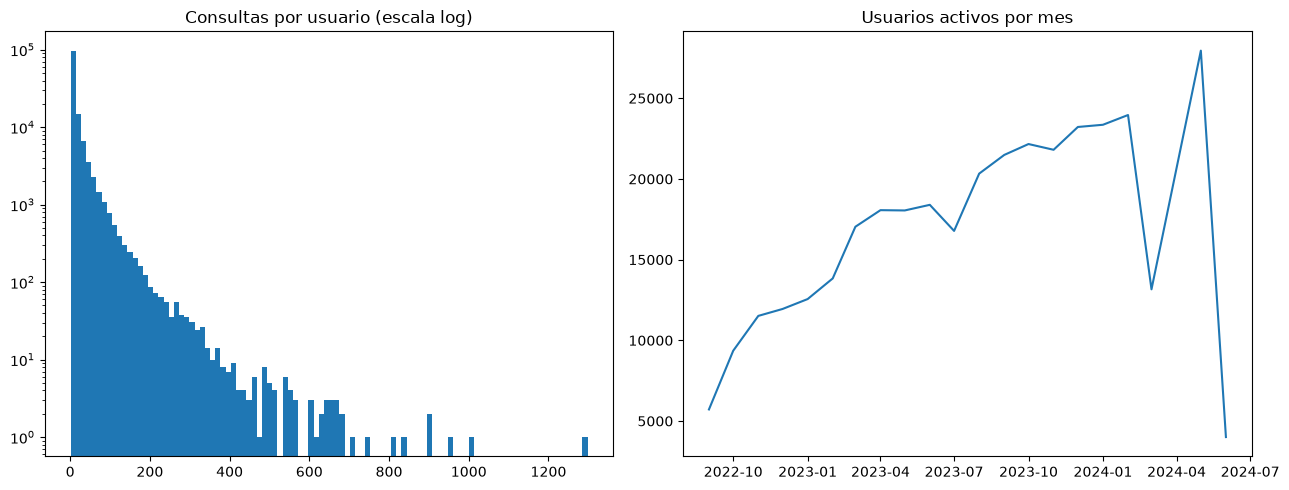

In [15]:
activos_mensual = df_consultas.sort("ts").group_by_dynamic("ts", every="1mo").agg(
    pl.col("userID").n_unique().alias("usuarios_activos")
)

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
ejes[0].hist(por_usuario["n_consultas"].to_numpy(), bins=100, log=True)
ejes[0].set_title("Consultas por usuario (escala log)")
ejes[1].plot(activos_mensual["ts"], activos_mensual["usuarios_activos"])
ejes[1].set_title("Usuarios activos por mes")
plt.tight_layout()
guardar_figura(fig, "analisis_usuarios")
plt.show()

## 8. Proporciones por variable y por zona

Distribución de consultas por municipio, por hora del día y por fin de semana — para entender no solo cuántas consultas hay, sino dónde y cuándo se concentran.

In [16]:
proporcion_municipio_origen = (
    df_consultas.group_by("origin_municipio")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / total_filas * 100).round(2).alias("pct"))
    .sort("n", descending=True)
)
print("Proporción de consultas por municipio de origen:")
proporcion_municipio_origen

Proporción de consultas por municipio de origen:


origin_municipio,n,pct
str,u32,f64
"""Cochabamba""",1661981,86.22
"""Sacaba""",92192,4.78
"""Quillacollo""",64300,3.34
"""Colcapirhua""",55338,2.87
"""Tiquipaya""",45294,2.35
…,…,…
"""Vacas""",2,0.0
"""Bolivar""",2,0.0
"""Tacopaya""",2,0.0


Proporción por fin de semana:
shape: (2, 3)
┌─────────┬─────────┬───────┐
│ weekend ┆ n       ┆ pct   │
│ ---     ┆ ---     ┆ ---   │
│ i64     ┆ u32     ┆ f64   │
╞═════════╪═════════╪═══════╡
│ 0       ┆ 1488379 ┆ 77.21 │
│ 1       ┆ 439296  ┆ 22.79 │
└─────────┴─────────┴───────┘


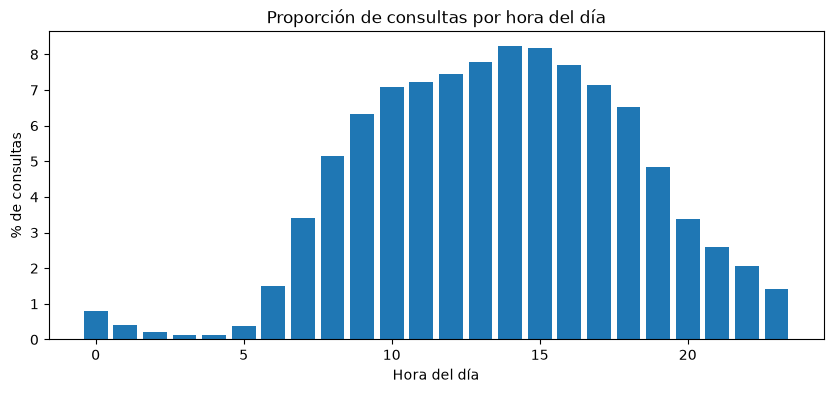

In [17]:
proporcion_hora = (
    df_consultas.group_by("hour")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / total_filas * 100).round(2).alias("pct"))
    .sort("hour")
)
proporcion_fin_semana = (
    df_consultas.group_by("weekend")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / total_filas * 100).round(2).alias("pct"))
)
print("Proporción por fin de semana:")
print(proporcion_fin_semana)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(proporcion_hora["hour"].to_numpy(), proporcion_hora["pct"].to_numpy())
ax.set_xlabel("Hora del día")
ax.set_ylabel("% de consultas")
ax.set_title("Proporción de consultas por hora del día")
guardar_figura(fig, "proporcion_por_hora")
plt.show()

## 9. Celdas H3 al formato Kontur (resolución 8)

Kontur Population describe sus hexágonos como "H3 hexagons de 400m". Antes de asumir que eso es resolución 8, se mide la geometría real de H3 en código.

In [18]:
borde_promedio_r8_m = h3.average_hexagon_edge_length(8, unit="m")
area_promedio_r8_km2 = h3.average_hexagon_area(8, unit="km^2")
apotema_r8_m = borde_promedio_r8_m * (3 ** 0.5) / 2  # inradio del hexágono regular

print(f"H3 resolución 8 — borde promedio (lado del hexágono): {borde_promedio_r8_m:.1f} m")
print(f"H3 resolución 8 — apotema (centro a lado):            {apotema_r8_m:.1f} m")
print(f"H3 resolución 8 — área promedio:                      {area_promedio_r8_km2:.4f} km²")

H3 resolución 8 — borde promedio (lado del hexágono): 531.4 m
H3 resolución 8 — apotema (centro a lado):            460.2 m
H3 resolución 8 — área promedio:                      0.7373 km²


**Nota metodológica**: el borde real de un hexágono H3 r8 mide ~531 m, no ~400 m ni los ~460 m que sugiere un comentario heredado en `trufi_ds/config.py` (esa cifra es en realidad el **apotema** — distancia del centro al borde — no el borde en sí). El "400m" de Kontur es una descripción redondeada/informal de la resolución 8, no una medida exacta que deba coincidir matemáticamente con ninguna de estas cifras. La prueba definitiva de que Kontur usa resolución 8 no es esta aritmética, sino comprobar `h3.get_resolution()` sobre un identificador H3 real de su dataset — eso ya se hizo en el trabajo de integración con Kontur (fuera del alcance de este notebook) y confirmó resolución 8. Aquí solo se deja registrada la geometría real para no repetir la cifra heredada sin verificarla.

In [19]:
RESOLUCION_H3 = 8


def a_celda_h3(lat, lon, resolucion=RESOLUCION_H3):
    try:
        return h3.latlng_to_cell(lat, lon, resolucion)
    except Exception:
        return None


df_consultas = df_consultas.with_columns([
    pl.struct(["lat_orig", "lon_orig"]).map_elements(
        lambda s: a_celda_h3(s["lat_orig"], s["lon_orig"]), return_dtype=pl.Utf8
    ).alias("h3_orig"),
    pl.struct(["lat_dest", "lon_dest"]).map_elements(
        lambda s: a_celda_h3(s["lat_dest"], s["lon_dest"]), return_dtype=pl.Utf8
    ).alias("h3_dest"),
])

celdas_origen = df_consultas.group_by("h3_orig").agg([
    pl.len().alias("n_consultas"),
    pl.col("userID").n_unique().alias("n_usuarios"),
]).sort("n_consultas", descending=True)

celdas_destino = df_consultas.group_by("h3_dest").agg([
    pl.len().alias("n_consultas"),
    pl.col("userID").n_unique().alias("n_usuarios"),
]).sort("n_consultas", descending=True)

celdas_origen.write_parquet(CARPETA_INTERIM / "h3_orig.parquet")
celdas_destino.write_parquet(CARPETA_INTERIM / "h3_dest.parquet")

n_celdas_origen, n_celdas_destino = len(celdas_origen), len(celdas_destino)
top10_pct_origen = celdas_origen.head(10)["n_consultas"].sum() / total_filas * 100
print(f"Celdas H3 con consultas de origen: {n_celdas_origen:,}")
print(f"Celdas H3 con consultas de destino: {n_celdas_destino:,}")
print(f"Top 10 celdas de origen concentran: {top10_pct_origen:.1f}% de las consultas")
print(
    "\nEsta columna 'n_consultas' por celda es la variable objetivo base "
    "del proyecto — de aquí derivan tanto la tabla de indicadores de la "
    "Etapa 2 como la tabla minable de OE1."
)
celdas_origen.head(10)

Celdas H3 con consultas de origen: 1,523
Celdas H3 con consultas de destino: 1,840
Top 10 celdas de origen concentran: 42.0% de las consultas

Esta columna 'n_consultas' por celda es la variable objetivo base del proyecto — de aquí derivan tanto la tabla de indicadores de la Etapa 2 como la tabla minable de OE1.


h3_orig,n_consultas,n_usuarios
str,u32,u32
"""888b2c8a39fffff""",152531,34338
"""888b2c8a3bfffff""",112588,28297
"""888b2c8ae5fffff""",92161,21983
"""888b2c8a15fffff""",90690,26849
"""888b2c8a03fffff""",80066,23750
"""888b2c8a31fffff""",77460,19966
"""888b2c8a33fffff""",59694,17032
"""888b2c8859fffff""",49864,15161
"""888b2c8aedfffff""",47832,15516


Para graficar, se descartan las celdas cuyo centroide cae fuera del bbox amplio de Bolivia (los mismos ~15 registros de coordenadas imposibles de la sección 6.2) — si no, un puñado de celdas a miles de km de Cochabamba arruina la escala del mapa. Los datos completos (sin este filtro) siguen intactos en `h3_orig.parquet`.

Celdas graficadas: 1,516 de 1,523


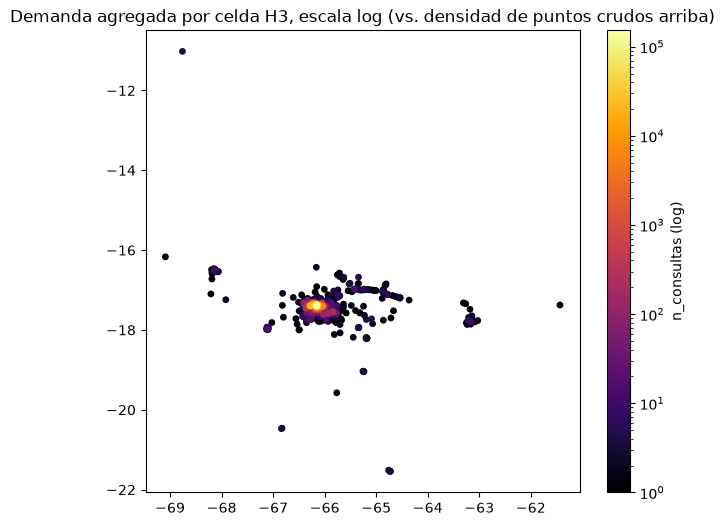

In [20]:
muestra_celdas = celdas_origen.to_pandas()
coords = muestra_celdas["h3_orig"].dropna().apply(h3.cell_to_latlng)
muestra_celdas["lat"] = coords.apply(lambda c: c[0])
muestra_celdas["lon"] = coords.apply(lambda c: c[1])
muestra_celdas_bolivia = muestra_celdas[
    muestra_celdas["lat"].between(BBOX_BOLIVIA["lat_min"], BBOX_BOLIVIA["lat_max"])
    & muestra_celdas["lon"].between(BBOX_BOLIVIA["lon_min"], BBOX_BOLIVIA["lon_max"])
].sort_values("n_consultas")  # ascendente: las celdas de mayor demanda se dibujan al final (encima)
print(f"Celdas graficadas: {len(muestra_celdas_bolivia):,} de {len(muestra_celdas):,}")

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(7, 6))
dispersión = ax.scatter(
    muestra_celdas_bolivia["lon"], muestra_celdas_bolivia["lat"],
    c=muestra_celdas_bolivia["n_consultas"], cmap="inferno", s=15,
    norm=LogNorm(vmin=1, vmax=muestra_celdas_bolivia["n_consultas"].max()),
)
ax.set_title("Demanda agregada por celda H3, escala log (vs. densidad de puntos crudos arriba)")
plt.colorbar(dispersión, ax=ax, label="n_consultas (log)")
guardar_figura(fig, "mapa_celdas_h3_agregadas")
plt.show()

## 10. Consolidación final

### Gráfico de evolución: cuántas filas toca cada hallazgo

No para eliminar filas aquí (eso es trabajo de la Etapa 2), sino para mostrar visualmente el argumento detrás de cada decisión: cuántas filas *se verían* afectadas por cada criterio, a medida que se van descubriendo.

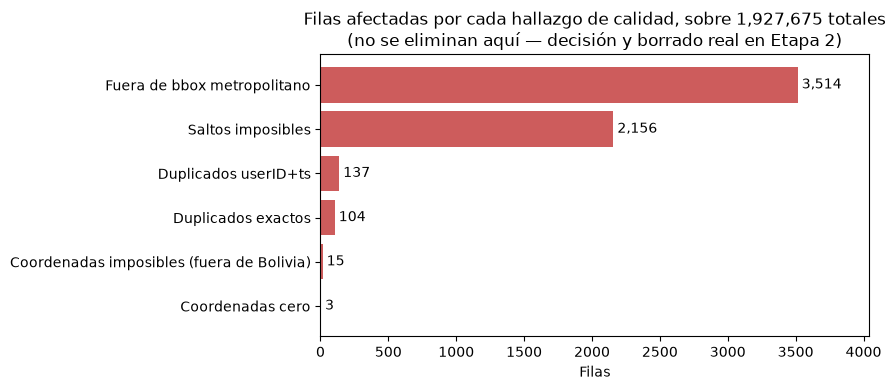

In [21]:
# El total (1.9M) no es comparable en la misma escala que los hallazgos
# (cientos a miles de filas) -> va en el título, no como una barra más.
hallazgos = [
    ("Duplicados exactos", duplicados_exactos),
    ("Duplicados userID+ts", duplicados_user_ts),
    ("Coordenadas cero", coordenadas_cero),
    ("Coordenadas imposibles (fuera de Bolivia)", n_coordenadas_imposibles),
    ("Saltos imposibles", n_saltos_sospechosos),
    ("Fuera de bbox metropolitano", n_fuera),
]
hallazgos.sort(key=lambda h: h[1])
etiquetas = [h[0] for h in hallazgos]
valores = [h[1] for h in hallazgos]

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.barh(etiquetas, valores, color="indianred")
ax.bar_label(barras, labels=[f"{v:,}" for v in valores], padding=3)
ax.set_xlabel("Filas")
ax.set_title(
    f"Filas afectadas por cada hallazgo de calidad, sobre {total_filas:,} totales\n"
    "(no se eliminan aquí — decisión y borrado real en Etapa 2)"
)
ax.margins(x=0.15)
plt.tight_layout()
guardar_figura(fig, "evolucion_hallazgos_calidad")
plt.show()

### Resumen ejecutable (regenera `README.md`)

In [22]:
resumen = f"""# Comprensión de datos — Trufi App Cochabamba

Generado por `notebooks/01_comprension_datos.ipynb`. Sin archivos `.md` extensos por sección — el detalle vive en el notebook; este README es un resumen ejecutable, no un ensayo.

## Estado del dataset

- Filas totales: {total_filas:,}
- Rango de fechas: {fecha_min} a {fecha_max}
- Usuarios únicos: {n_usuarios:,}
- Archivos fuente consolidados: {df_consultas['source_file'].n_unique()} (esperado 85)
- Columnas: {', '.join(df_consultas.columns)}

## Hallazgos clave

- Esquema: {n_identicos}/{len(archivos_csv)} archivos idénticos a la referencia; 6 con nombres en inglés + Latin-1 (ver `schema_diff.csv`).
- Calidad: {duplicados_exactos:,} duplicados exactos (eliminar en Etapa 2); {duplicados_user_ts:,} duplicados userID+ts (conservar, sesionizar); {n_coordenadas_imposibles:,} filas con coordenadas físicamente imposibles para Bolivia (distinto de las {n_fuera:,} fuera del bbox metropolitano, la mayoría interurbanas legítimas).
- `distancia`: {conclusion_unidad}, línea recta (haversine/geodésica), correlación {correlacion:.6f}.
- Vacío temporal: {len(semanas_vacias)} semanas sin datos (estructural, no imputar).
- `userID`: a nivel {veredicto_individual}.
- H3 (resolución 8, borde ~{borde_promedio_r8_m:.0f}m, apotema ~{apotema_r8_m:.0f}m): {n_celdas_origen:,} celdas de origen, top 10 concentran {top10_pct_origen:.1f}% de la demanda.

## Figuras

Ver `reports/01_data_understanding/figuras/`.

## Salidas

- `data/interim/queries.parquet/` (dataset consolidado, particionado Hive)
- `data/interim/h3_orig.parquet`, `h3_dest.parquet` (agregados H3)
- `reports/01_data_understanding/schema_diff.csv`

## Próximo paso

OE1: construir la tabla minable a nivel celda H3 (población Kontur, cobertura GTFS, distancia a la Plaza 14 de Septiembre, rezagos k-ring) — ver `DECISIONES.md`.
"""

ruta_readme = CARPETA_REPORTES / "README.md"
ruta_readme.write_text(resumen)
print(f"Guardado: {ruta_readme}")

Guardado: /home/robvox/Desktop/trufi-data-science/reports/01_data_understanding/README.md
